# Buổi 8: Bài toán phân cụm

In [10]:
import numpy as np
import random, os
from IPython import display

import matplotlib.pyplot as plt          # vẽ hình
from collections import Counter

import pandas as pd
from sklearn.datasets import make_blobs  # tạo tập điểm phân bố Gaussian
from sklearn.cluster import KMeans       # thuật toán phân cụm k-means

import warnings
warnings.filterwarnings("ignore")

# cố định random-state để phục hồi lại kết quả thí nghiệm
random_state = 42
random.seed(random_state)
os.environ['PYTHONHASHSEED'] = str(random_state)
np.random.seed(random_state)

## Bài 1. Tập hợp điểm hai chiều

### 1. Tạo và hiển thị dữ liệu

Tạo và hiển thị tập hợp điểm dữ liệu $X_1$ có chứa $N=400$ điểm hai chiều. Những tập hợp này bao gồm 4 nhóm bằng nhau, mỗi nhóm có hàm mật độ theo phân phối Gaussian với mean $m_0=\left(0, 0\right)$, $m_1=\left(10, 0\right)$, $m_2=\left(0, 9\right)$, và $m_3=\left(9, 8\right)$ và ma trận covariance tương ứng $S_0=I$, $S_1=1.5I$, $S_2=1.1I$, và $S_3=0.5I$ nơi mà $
I = \begin{bmatrix}
 1 & 1\\ 
 1 & 1
\end{bmatrix}.
$

**Lưu ý**: 
+ **mean** là tâm của tập hợp điểm
+ **covariance** cho biết độ biến đổi của tập điểm xung quanh tâm. Giá trị càng lớn thì độ phân tán so với tâm càng xa và ngược lại.

In [11]:
# Sinh tập hợp điểm theo phân phối Gaussian
X1, y1 = make_blobs(n_samples    = 400,                         # số lượng điểm
                    centers      = [[0,0], [10,0],[0,9],[9,8]], # vị trí tâm
                    cluster_std  = [1, 1.5, 1.1, 0.5],          # độ phân tán
                    random_state = random_state,                # seed ngẫu nhiên
                   )

In [12]:
# lưu trữ trong pandas
df_points = pd.DataFrame(X1, columns=["x", "y"])
df_points["label"] = y1

# tính số lớp, tần số xuất hiện mỗi lớp
n_classes = len(np.unique(df_points["label"])) # tính số lớp dữ liệu
labels, cnts = np.unique(df_points["label"], return_counts=True)
n_cnts = dict(zip(labels, cnts))
print(f'+ labels={labels}\n+ cnts={cnts}\n+ n_cnts={n_cnts}')

# hiển thị dữ liệu
display.display(df_points)

+ labels=[0 1 2 3]
+ cnts=[100 100 100 100]
+ n_cnts={np.int64(0): np.int64(100), np.int64(1): np.int64(100), np.int64(2): np.int64(100), np.int64(3): np.int64(100)}


,x,y,label
0,0.372346,8.543183,2
1,-0.495072,9.685135,2
2,8.738638,8.524505,3
3,9.014159,8.014878,3
4,8.505198,7.937107,3
...,...,...,...
395,11.120940,0.915555,1
396,11.022929,-0.465400,1
397,-1.150994,0.375698,0
398,-2.718809,8.123415,2


Center 0: [-0.11556425  0.03402232]
Center 1: [10.19237309  0.06523147]
Center 2: [-0.04954113  8.86110005]
Center 3: [8.96175896 8.04720768]


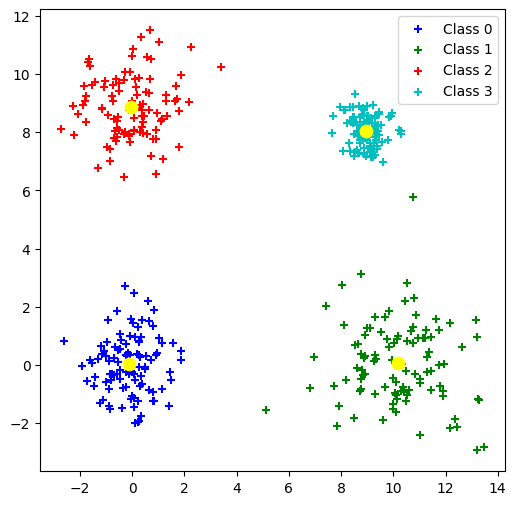

In [13]:
# màu của từng lớp
colors = {0:'b', 1:'g',2:'r',3:'c', 4:'m', 5:'y', 6:'k', 7:'w'} 

# vẽ tập dữ liệu điểm
plt.figure(figsize=(6,6))     # độ lớn của khung vẽ
for i in range(n_classes):
    # tính toán điểm trung tâm từng lớp
    p_center = np.mean(X1[y1==i], axis = 0) 
    print(f'Center {i}: {p_center}')
    # vẽ tập điểm
    plt.scatter(X1[y1==i, 0], X1[y1==i, 1], marker='+', 
                c = colors[i], label = f"Class {i}")
    # vẽ tâm
    plt.scatter(p_center[0], p_center[1], marker='o', 
                c='yellow', s = 80)
    pass # for
plt.legend()
plt.show()

### 2. Áp dụng thuật toán phân cụm

Thuật toán k-mean chia tập hợp $N$ mẫu $X_1$ thành $m$ cụm rời rạc $C$ (clusters), mỗi cụm được mô tả bằng giá trị trung bình của các mẫu trong cụm (thường được gọi là trung tâm cụm - centroid).

Thuật toán k-mean hướng tới chọn các centroids sao cho cực tiểu hóa độ đo khoảng cách (intertia) giữa các phần tử trong cụm (within-cluster). Độ đo hay dùng là tổng bình phương khoảng cách theo Euclide distance.

####  2.1. Số cụm m = 4 ngẫu nhiên

In [14]:
m = 4 # số cụm khởi tạo
kmeans = KMeans(n_clusters=m, random_state=random_state) # thuật toán kmean
kmeans.fit(X1); # huấn luyện tìm m cluster

cluster_centers = kmeans.cluster_centers_
cluster_inertia = kmeans.inertia_

# kiểm tra số mẫu phân lớp đúng
y_pred          = kmeans.labels_
correct_labels  = sum(y1 == y_pred) # tính độ chính xác

print(f'Centers:\n{cluster_centers}')
print(f'Inertia: {cluster_inertia}')
print(f'Correct Labels: {correct_labels} / {len(df_points)}')
print('Accuracy score: {0:0.2f}'. format(correct_labels/float(len(df_points))))

Centers:
[[ 1.01865125e+01  7.51565800e-03]
 [-4.95411256e-02  8.86110005e+00]
 [-1.15564255e-01  3.40223244e-02]
 [ 8.97968780e+00  8.02475114e+00]]
Inertia: 870.6509324177748
Correct Labels: 100 / 400
Accuracy score: 0.25


**Lưu ý**:
+ Intertia là độ đo khoảng cách giữa các phần tử trong cụm. Giá trị càng nhỏ là càng tốt và tiến tới 0 là tốt nhất.
+ Chúng ta chỉ đạt được độ chính xác thấp 25% do đây là mô hình unsupervised (học không giám sát)

Predict: [1 1 3 3 3 3 1 0 2 2 1 2 3 2 2 2 1 0 2 0] ...
Center 0: [1.01865125e+01 7.51565800e-03]
Center 1: [-0.04954113  8.86110005]
Center 2: [-0.11556425  0.03402232]
Center 3: [8.9796878  8.02475114]


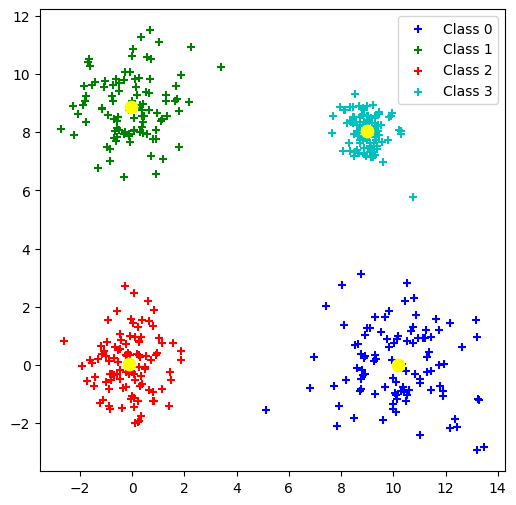

In [15]:
print(f'Predict: {y_pred[0:20]} ...')
# vẽ tập dữ liệu điểm dự đoán
plt.figure(figsize=(6,6))     # độ lớn của khung vẽ
for i in range(m):
    # Điểm trung tâm của lớp
    print(f'Center {i}: {cluster_centers[i]}')
    
    # vẽ tập điểm
    plt.scatter(X1[y_pred==i, 0], X1[y_pred==i, 1], marker='+', 
                c = colors[i], label = f"Class {i}")
    # vẽ tâm
    plt.scatter(cluster_centers[i, 0], cluster_centers[i, 1], marker='o', 
                c='yellow', s = 80)
    pass # for
plt.legend()
plt.show()

####  2.2. Số cụm m = 3 ngẫu nhiên

Centers:
[[ 9.59937239  4.08432411]
 [-0.04954113  8.86110005]
 [-0.06354779  0.01847179]]
Inertia: 4135.476824302056
Correct Labels: 0 / 400
Accuracy score: 0.00

Predict: [1 1 0 0 0 0 1 0 2 2 1 2 0 2 2 2 1 0 2 0] ...
Center 0: [9.59937239 4.08432411]
Center 1: [-0.04954113  8.86110005]
Center 2: [-0.06354779  0.01847179]


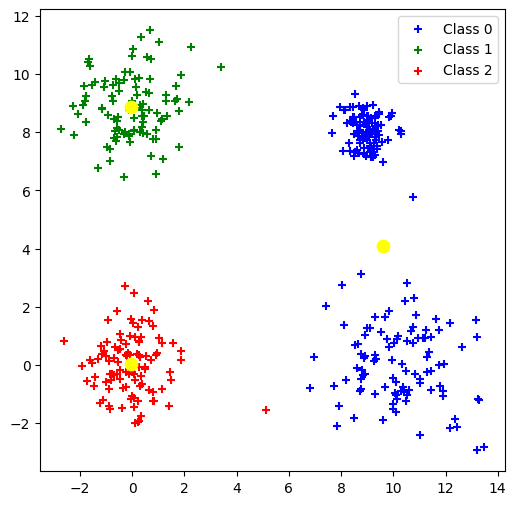

In [16]:
m = 3 # số cụm khởi tạo
kmeans = KMeans(n_clusters=m, random_state=random_state) # thuật toán kmean
kmeans.fit(X1); # huấn luyện tìm m cluster

cluster_centers = kmeans.cluster_centers_
cluster_inertia = kmeans.inertia_

# kiểm tra số mẫu phân lớp đúng
y_pred          = kmeans.labels_
correct_labels = sum(y1 == y_pred)

print(f'Centers:\n{cluster_centers}')
print(f'Inertia: {cluster_inertia}')
print(f'Correct Labels: {correct_labels} / {len(df_points)}')
print('Accuracy score: {0:0.2f}'. format(correct_labels/float(len(df_points))))

print()
print(f'Predict: {y_pred[0:20]} ...')
# vẽ tập dữ liệu điểm dự đoán
plt.figure(figsize=(6,6))     # độ lớn của khung vẽ
for i in range(m):
    # Điểm trung tâm của lớp
    print(f'Center {i}: {cluster_centers[i]}')
    
    # vẽ tập điểm
    plt.scatter(X1[y_pred==i, 0], X1[y_pred==i, 1], marker='+', 
                c = colors[i], label = f"Class {i}")
    # vẽ tâm
    plt.scatter(cluster_centers[i, 0], cluster_centers[i, 1], marker='o', 
                c='yellow', s = 80)
    pass # for
plt.legend()
plt.show()

#### 2.3. Số cụm m = 5 ngẫu nhiên

Centers:
[[ 8.99671126  0.04820064]
 [-0.04954113  8.86110005]
 [-0.11556425  0.03402232]
 [ 8.9796878   8.02475114]
 [11.45067631 -0.03571213]]
Inertia: 721.570555397345
Correct Labels: 100 / 400
Accuracy score: 0.25

Predict: [1 1 3 3 3 3 1 4 2 2 1 2 3 2 2 2 1 0 2 4] ...
Center 0: [8.99671126 0.04820064]
Center 1: [-0.04954113  8.86110005]
Center 2: [-0.11556425  0.03402232]
Center 3: [8.9796878  8.02475114]
Center 4: [11.45067631 -0.03571213]


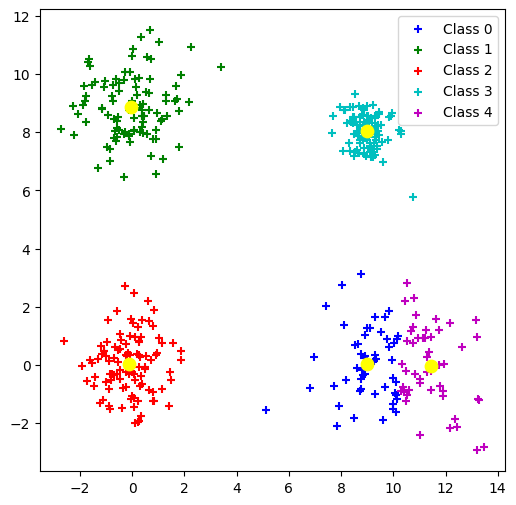

In [17]:
m = 5 # số cụm khởi tạo
kmeans = KMeans(n_clusters=m, random_state=random_state) # thuật toán kmean
kmeans.fit(X1); # huấn luyện tìm m cluster

cluster_centers = kmeans.cluster_centers_
cluster_inertia = kmeans.inertia_

# kiểm tra số mẫu phân lớp đúng
y_pred          = kmeans.labels_
correct_labels = sum(y1 == y_pred)

print(f'Centers:\n{cluster_centers}')
print(f'Inertia: {cluster_inertia}')
print(f'Correct Labels: {correct_labels} / {len(df_points)}')
print('Accuracy score: {0:0.2f}'. format(correct_labels/float(len(df_points))))

print()
print(f'Predict: {y_pred[0:20]} ...')
# vẽ tập dữ liệu điểm dự đoán
plt.figure(figsize=(6,6))     # độ lớn của khung vẽ
for i in range(m):
    # Điểm trung tâm của lớp
    print(f'Center {i}: {cluster_centers[i]}')
    
    # vẽ tập điểm
    plt.scatter(X1[y_pred==i, 0], X1[y_pred==i, 1], marker='+', 
                c = colors[i], label = f"Class {i}")
    # vẽ tâm
    plt.scatter(cluster_centers[i, 0], cluster_centers[i, 1], marker='o', 
                c='yellow', s = 80)
    pass # for
plt.legend()
plt.show()

#### 2.4. Số cụm m = 4 xác định trước

Tập $m=4$ cụm xác định trước lần lượt là $\theta_1 = \left(-2, -2\right)$, $\theta_2 = \left(-2.1, -2.1\right)$, $\theta_3 = \left(-2.0, -2.2\right)$, $\theta_4 = \left(-2.1, -2.2\right)$

Centers:
[[-1.15564255e-01  3.40223244e-02]
 [-4.95411256e-02  8.86110005e+00]
 [ 1.01865125e+01  7.51565800e-03]
 [ 8.97968780e+00  8.02475114e+00]]
Inertia: 870.6509324177748
Correct Labels: 200 / 400
Accuracy score: 0.50

Predict: [1 1 3 3 3 3 1 2 0 0 1 0 3 0 0 0 1 2 0 2] ...
Center 0: [-0.11556425  0.03402232]
Center 1: [-0.04954113  8.86110005]
Center 2: [1.01865125e+01 7.51565800e-03]
Center 3: [8.9796878  8.02475114]


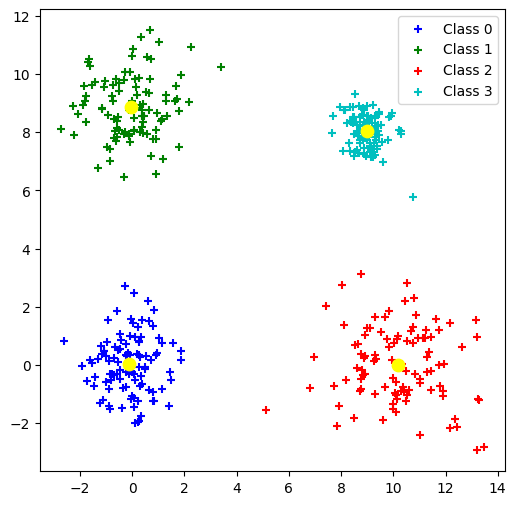

In [18]:
m = 4 # số cụm khởi tạo
kmeans = KMeans(n_clusters=m, 
                init = np.array([[-2,-2], [-2.1, -2.1], [-2.0, -2.2], [-2.1,-2.2]]),
                n_init = 1, # chỉ chạy 1 lần k_means
                random_state=random_state) # thuật toán kmean
kmeans.fit(X1); # huấn luyện tìm m cluster

cluster_centers = kmeans.cluster_centers_
cluster_inertia = kmeans.inertia_

# kiểm tra số mẫu phân lớp đúng
y_pred          = kmeans.labels_
correct_labels = sum(y1 == y_pred)

print(f'Centers:\n{cluster_centers}')
print(f'Inertia: {cluster_inertia}')
print(f'Correct Labels: {correct_labels} / {len(df_points)}')
print('Accuracy score: {0:0.2f}'. format(correct_labels/float(len(df_points))))

print()
print(f'Predict: {y_pred[0:20]} ...')
# vẽ tập dữ liệu điểm dự đoán
plt.figure(figsize=(6,6))     # độ lớn của khung vẽ
for i in range(m):
    # Điểm trung tâm của lớp
    print(f'Center {i}: {cluster_centers[i]}')
    
    # vẽ tập điểm
    plt.scatter(X1[y_pred==i, 0], X1[y_pred==i, 1], marker='+', 
                c = colors[i], label = f"Class {i}")
    # vẽ tâm
    plt.scatter(cluster_centers[i, 0], cluster_centers[i, 1], marker='o', 
                c='yellow', s = 80)
    pass # for
plt.legend()
plt.show()

### 3. Tìm số lượng cụm tối ưu bởi điểm cong (elbow method)

+ Chúng ta thực hiện k-means nhiều lần với k=2, 3, ... 
+ Vẽ đồ thị độ đo khoảng cách giữa các phần tử trong cụm
+ Tìm điểm cong quan trọng của đồ thị

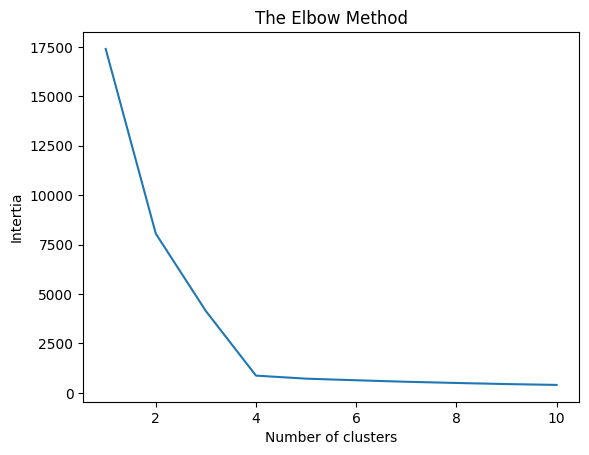

In [19]:
list_intertia = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters = i,      # số cluster
                    init = 'k-means++',  # khởi tạo ngẫu nhiên dùng k-means++
                    max_iter = 300,      # số lần lặp trong thuật toán
                    n_init = 10,         # số lần chạy lại k-means và lấy tốt nhất
                    random_state = random_state,
                   )
    kmeans.fit(X1)
    list_intertia.append(kmeans.inertia_)
plt.plot(range(1, 11), list_intertia)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('Intertia')
plt.show()

+ Hình trên cho thấy số lượng cluster tối ưu là 4

# Bài 2. Bài tập áp dụng

Áp dụng thuật toán k-means cho tập dữ liệu sau:
+ Tập điểm dữ liệu $X_2$ gồm 400 điểm 2 chiều chứa 4 lớp với số lượng phần tử bằng nhau. Các tập hợp điểm trong lớp tuân theo phân phối Gaussian với means $m_0=\left(0, 0\right)$, $m_1=\left(4, 0\right)$, $m_2=\left(0, 4\right)$, và $m_3=\left(5, 4\right)$ với các covariance matrices tương ứng $S_0=I$, $S_1=1.5I$, $S_2=1.1I$, $S_3=0.5I$.

+ Tập điểm dữ liệu $X_3$ gồm 300 điểm 2 chiều chỉ có 1 lớp dữ liệu với mean $m_1=\left(0, 0\right)$ và $S_1 = I$.

## 1. Tạo tập dữ liệu X2 và X3

## X2: 400 điểm, 4 cụm Gaussian

In [20]:
X2, y2 = make_blobs(n_samples=400,
                    centers=[[0, 0], [4, 0], [0, 4], [5, 4]],
                    cluster_std=[1.0, 1.5, 1.1, 0.5],
                    random_state=random_state)

## X3: 300 điểm, chỉ 1 cụm

In [21]:
X3, y3 = make_blobs(n_samples=300,
                    centers=[[0, 0]],
                    cluster_std=[1.0],
                    random_state=random_state)

## Lưu vào DataFrame để dễ quan sát

In [22]:
df_X2 = pd.DataFrame(X2, columns=['x', 'y'])
df_X2['true_label'] = y2

df_X3 = pd.DataFrame(X3, columns=['x', 'y'])

print(f"X2 shape: {X2.shape} - 4 cụm")
print(f"X3 shape: {X3.shape} - 1 cụm\n")

X2 shape: (400, 2) - 4 cụm
X3 shape: (300, 2) - 1 cụm



## 2. Trực quan hóa dữ liệu

In [23]:
plt.figure(figsize=(12, 5))

<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

## Vẽ X2

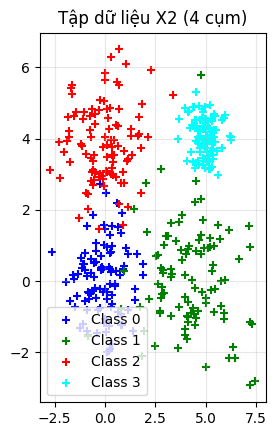

In [24]:
plt.subplot(1, 2, 1)
plt.title("Tập dữ liệu X2 (4 cụm)")
colors = ['blue', 'green', 'red', 'cyan']
for i in range(4):
    plt.scatter(X2[y2 == i, 0], X2[y2 == i, 1], 
                c=colors[i], marker='+', label=f'Class {i}')
plt.legend()
plt.grid(True, alpha=0.3)

## Vẽ X3

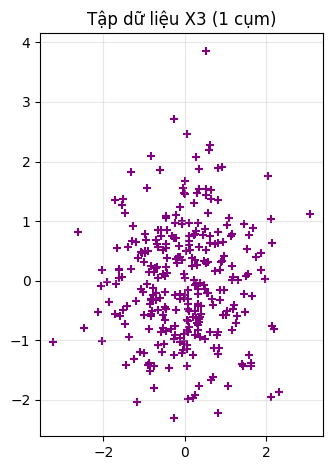

In [25]:
plt.subplot(1, 2, 2)
plt.title("Tập dữ liệu X3 (1 cụm)")
plt.scatter(X3[:, 0], X3[:, 1], c='purple', marker='+')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Áp dụng K-Means cho X2 (4 cụm)

In [26]:
print("=== Kết quả trên tập X2 (4 cụm) ===\n")

kmeans2 = KMeans(n_clusters=4, 
                 init='k-means++',
                 n_init=10,
                 max_iter=300,
                 random_state=random_state)

kmeans2.fit(X2)

centers2 = kmeans2.cluster_centers_
inertia2 = kmeans2.inertia_
y_pred2  = kmeans2.labels_

=== Kết quả trên tập X2 (4 cụm) ===



## Độ chính xác so với nhãn thật (chỉ mang tính tham khảo)

In [27]:
correct2 = sum(y2 == y_pred2)
accuracy2 = correct2 / len(y2)

print(f"Inertia (X2)       : {inertia2:.2f}")
print(f"Số điểm đúng       : {correct2}/{len(y2)}")
print(f"Accuracy (tham khảo): {accuracy2:.4f}\n")

Inertia (X2)       : 746.48
Số điểm đúng       : 197/400
Accuracy (tham khảo): 0.4925



## Vẽ kết quả phân cụm X2

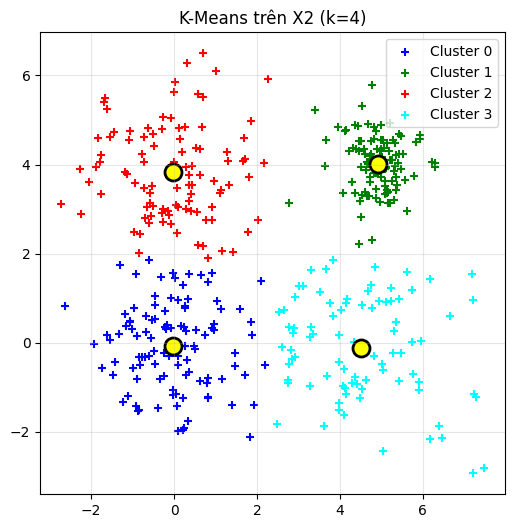

In [28]:
plt.figure(figsize=(6,6))
plt.title("K-Means trên X2 (k=4)")
for i in range(4):
    plt.scatter(X2[y_pred2 == i, 0], X2[y_pred2 == i, 1], 
                c=colors[i], marker='+', label=f'Cluster {i}')
    plt.scatter(centers2[i, 0], centers2[i, 1], 
                c='yellow', marker='o', s=150, edgecolors='black', linewidth=2)

plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 4. Tìm số cụm tối ưu cho X2 bằng Elbow Method

=== Tìm số cụm tối ưu cho X2 bằng Elbow Method ===



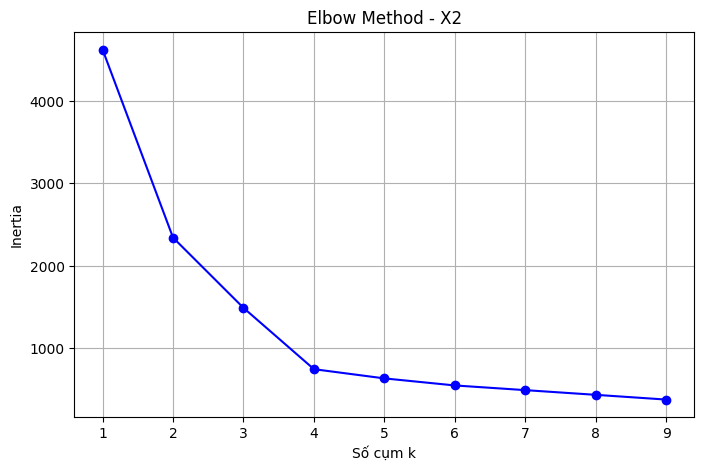

→ Từ đồ thị Elbow, số cụm tối ưu cho X2 là **k = 4**


In [29]:
print("=== Tìm số cụm tối ưu cho X2 bằng Elbow Method ===\n")

inertias = []
K_range = range(1, 10)

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', 
                n_init=10, max_iter=300, random_state=random_state)
    km.fit(X2)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertias, 'bo-')
plt.title('Elbow Method - X2')
plt.xlabel('Số cụm k')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()

print("→ Từ đồ thị Elbow, số cụm tối ưu cho X2 là **k = 4**")

## 5. Áp dụng K-Means cho X3 (1 cụm)

In [30]:
print("\n=== Kết quả trên tập X3 (1 cụm) ===\n")

kmeans3 = KMeans(n_clusters=1, 
                 init='k-means++',
                 n_init=10,
                 max_iter=300,
                 random_state=random_state)

kmeans3.fit(X3)

print(f"Inertia (X3) : {kmeans3.inertia_:.2f}")
print("→ Với 1 cụm, K-Means chỉ tìm được tâm của toàn bộ dữ liệu.")


=== Kết quả trên tập X3 (1 cụm) ===

Inertia (X3) : 566.14
→ Với 1 cụm, K-Means chỉ tìm được tâm của toàn bộ dữ liệu.


## Vẽ X3 với tâm cụm

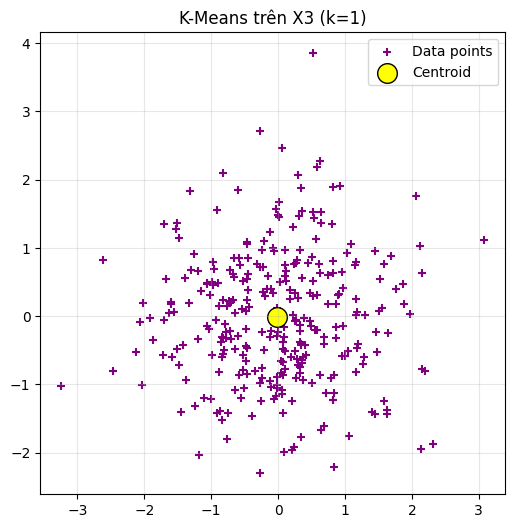

In [31]:
plt.figure(figsize=(6,6))
plt.title("K-Means trên X3 (k=1)")
plt.scatter(X3[:, 0], X3[:, 1], c='purple', marker='+', label='Data points')
plt.scatter(kmeans3.cluster_centers_[0, 0], 
            kmeans3.cluster_centers_[0, 1], 
            c='yellow', marker='o', s=200, edgecolors='black', label='Centroid')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Kết thúc